In [17]:
# Imports
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")

PennyLane version: 0.40.0
PyTorch version: 2.2.2


In [18]:
# Configuration
n_qubits = 8
n_layers = 3  
n_train_pairs = 800  
n_test_pairs = 200
epochs = 40
batch_per_epoch = 80  

# Device setup
dev = qml.device('default.qubit', wires=2*n_qubits + 1)
print(f"Configuration:")
print(f"  - Qubits per image: {n_qubits}")
print(f"  - Variational layers: {n_layers}")
print(f"  - Total circuit qubits: {2*n_qubits + 1}")
print(f"  - Training pairs: {n_train_pairs}")
print(f"  - Epochs: {epochs}")

Configuration:
  - Qubits per image: 8
  - Variational layers: 3
  - Total circuit qubits: 17
  - Training pairs: 800
  - Epochs: 40


In [19]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Larger subsets for better generalization
train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")

Training samples: 5000
Test samples: 1000


In [20]:
# Dimension Reducer with Dropout 
class DimensionReducer(nn.Module):
    def __init__(self, input_dim=784, output_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),  # Dropout to prevent overfitting
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.2),  # Additional dropout
            nn.Linear(64, output_dim)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        features = self.net(x)
        # Scale to [0, π] for rotation gates
        scaled = torch.sigmoid(features) * np.pi
        return scaled

# Test the encoder
test_encoder = DimensionReducer(784, n_qubits)
dummy_input = torch.randn(1, 1, 28, 28)
dummy_output = test_encoder(dummy_input)
print(f"Encoder output shape: {dummy_output.shape}")
print(f"Encoder output range: [{dummy_output.min().item():.3f}, {dummy_output.max().item():.3f}]")
print(f"Encoder parameters: {sum(p.numel() for p in test_encoder.parameters())}")

Encoder output shape: torch.Size([1, 8])
Encoder output range: [0.980, 2.066]
Encoder parameters: 109640


In [21]:
# Quantum Circuit with DATA RE-UPLOADING

@qml.qnode(dev, interface='torch', diff_method='backprop')
def swap_test_circuit(features1, features2, weights):
    """
    SWAP test circuit with DATA RE-UPLOADING for increased expressivity.
    
    Data re-uploading: The data is re-encoded at each layer, alternating
    with trainable gates. This makes the circuit a universal function
    approximator (Pérez-Salinas et al., Quantum 4, 226, 2020).
    
    Args:
        features1: Encoded features for image 1 (n_qubits,)
        features2: Encoded features for image 2 (n_qubits,)
        weights: Trainable parameters (n_layers, n_qubits, 3)
    
    Returns:
        Expectation value of Z on ancilla
    """
    ancilla = 0
    reg1 = list(range(1, n_qubits + 1))
    reg2 = list(range(n_qubits + 1, 2*n_qubits + 1))
    
    # Embed first image with DATA RE-UPLOADING
    for layer in range(n_layers):
        for i, wire in enumerate(reg1):
            qml.RY(features1[i], wires=wire)
        
        # Trainable rotations
        for i, wire in enumerate(reg1):
            qml.RX(weights[layer, i, 0], wires=wire)
            qml.RY(weights[layer, i, 1], wires=wire)
            qml.RZ(weights[layer, i, 2], wires=wire)
        
        # Entanglement (ring topology)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[reg1[i], reg1[i+1]])
        qml.CNOT(wires=[reg1[-1], reg1[0]])  
    
    # Embed second image with DATA RE-UPLOADING 
    for layer in range(n_layers):
        for i, wire in enumerate(reg2):
            qml.RY(features2[i], wires=wire)
        
        # Trainable rotations (same weights = same embedding function)
        for i, wire in enumerate(reg2):
            qml.RX(weights[layer, i, 0], wires=wire)
            qml.RY(weights[layer, i, 1], wires=wire)
            qml.RZ(weights[layer, i, 2], wires=wire)
        
        # Entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[reg2[i], reg2[i+1]])
        qml.CNOT(wires=[reg2[-1], reg2[0]])
    
    # ===== SWAP Test =====
    qml.Hadamard(wires=ancilla)
    for i in range(n_qubits):
        qml.CSWAP(wires=[ancilla, reg1[i], reg2[i]])
    qml.Hadamard(wires=ancilla)
    
    return qml.expval(qml.PauliZ(ancilla))

# Draw the circuit
print("Circuit structure (with data re-uploading):")
print(f"Each register: [RY(data) → RX,RY,RZ → CNOT ring] × {n_layers} layers")

Circuit structure (with data re-uploading):
Each register: [RY(data) → RX,RY,RZ → CNOT ring] × 3 layers


In [22]:
# Contrastive Loss Function

def contrastive_loss(fidelity, same_class, margin=0.4):
    """
    Contrastive loss with margin.
    
    Args:
        fidelity: Computed fidelity in [0, 1]
        same_class: Boolean or 1/0 indicating if pair is same class
        margin: Minimum separation for different classes
    
    Returns:
        Loss value (scalar tensor)
    """
    if same_class:
        # Same class: want fidelity close to 1
        loss = (1.0 - fidelity) ** 2
    else:
        # Different class: want fidelity below margin
        # Only penalize if fidelity > margin
        loss = torch.clamp(fidelity - margin, min=0) ** 2
    
    return loss

In [23]:
# Complete Model

class QuantumContrastiveModel(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
        # Classical encoder with dropout
        self.reducer = DimensionReducer(input_dim=784, output_dim=n_qubits)
        
        # Quantum circuit weights
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits, 3) * 0.3)
    
    def encode(self, img):
        """Get quantum features for a single image."""
        return self.reducer(img)
    
    def forward(self, img1, img2):
        """
        Compute fidelity between two images.
        """
        # Get classical features
        f1 = self.reducer(img1).squeeze()
        f2 = self.reducer(img2).squeeze()
        
        # Compute SWAP test
        exp_val = swap_test_circuit(f1, f2, self.weights)
        
        # Convert expectation value to fidelity
        fidelity = (1 + exp_val) / 2
        
        return fidelity

# Initialize model
model = QuantumContrastiveModel(n_qubits, n_layers)
print(f"Model parameters:")
print(f"  - Reducer: {sum(p.numel() for p in model.reducer.parameters())} params")
print(f"  - Quantum weights: {model.weights.numel()} params")
print(f"  - Total: {sum(p.numel() for p in model.parameters())} params")

Model parameters:
  - Reducer: 109640 params
  - Quantum weights: 72 params
  - Total: 109712 params


In [24]:
# Create Training Pairs

def create_pairs(dataset, num_pairs):
    """Create balanced positive and negative pairs."""
    pairs = []
    labels = []
    
    # Group indices by class
    class_indices = {i: [] for i in range(10)}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        class_indices[int(label)].append(idx)
    
    valid_classes = [c for c in range(10) if len(class_indices[c]) >= 2]
    
    for _ in range(num_pairs // 2):
        # Positive pair (same class)
        cls = np.random.choice(valid_classes)
        idx1, idx2 = np.random.choice(class_indices[cls], 2, replace=False)
        pairs.append((int(idx1), int(idx2)))
        labels.append(1)
        
        # Negative pair (different classes)
        cls1, cls2 = np.random.choice(valid_classes, 2, replace=False)
        idx1 = int(np.random.choice(class_indices[cls1]))
        idx2 = int(np.random.choice(class_indices[cls2]))
        pairs.append((int(idx1), int(idx2)))
        labels.append(0)
    
    return pairs, labels

# Create pairs
train_pairs, train_labels = create_pairs(train_subset, n_train_pairs)
test_pairs, test_labels = create_pairs(test_subset, n_test_pairs)

print(f"Training pairs: {len(train_pairs)} ({sum(train_labels)} positive, {len(train_labels) - sum(train_labels)} negative)")
print(f"Test pairs: {len(test_pairs)} ({sum(test_labels)} positive, {len(test_labels) - sum(test_labels)} negative)")

Training pairs: 800 (400 positive, 400 negative)
Test pairs: 200 (100 positive, 100 negative)


In [25]:
# Verify Feature Diversity

print("Checking feature diversity across different digits...")
model.eval()
with torch.no_grad():
    features_by_class = {}
    for i in range(min(100, len(train_subset))):
        img, label = train_subset[i]
        features = model.encode(img.unsqueeze(0)).squeeze().numpy()
        label = int(label)
        if label not in features_by_class:
            features_by_class[label] = []
        features_by_class[label].append(features)
    
    print("\nMean features per digit class:")
    for label in sorted(features_by_class.keys())[:5]:
        mean_feat = np.mean(features_by_class[label], axis=0)
        print(f"  Digit {label}: {mean_feat.round(3)}")
    
    all_features = np.vstack([f for feats in features_by_class.values() for f in feats])
    print(f"\nOverall feature std per dimension: {all_features.std(axis=0).round(3)}")

Checking feature diversity across different digits...

Mean features per digit class:
  Digit 0: [1.218 1.908 1.175 1.51  1.356 1.608 1.756 1.492]
  Digit 1: [1.366 1.696 1.499 1.192 1.775 1.465 1.708 1.513]
  Digit 2: [1.404 1.858 1.238 1.434 1.495 1.532 1.502 1.519]
  Digit 3: [1.548 1.695 1.322 1.203 1.659 1.5   1.965 1.459]
  Digit 4: [1.375 1.814 1.225 1.236 1.643 1.343 1.529 1.293]

Overall feature std per dimension: [0.193 0.172 0.2   0.214 0.223 0.195 0.231 0.157]


In [26]:
# Training Loop with Early Stopping

# Lower learning rates to prevent overfitting
optimizer = torch.optim.Adam([
    {'params': model.reducer.parameters(), 'lr': 0.002},  # Reduced from 0.005
    {'params': [model.weights], 'lr': 0.02}               # Reduced from 0.05
])

# Learning rate scheduler for gradual decay
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# Training history
history = {
    'loss': [],
    'train_pos_fid': [],
    'train_neg_fid': [],
    'train_gap': [],
    'test_pos_fid': [],
    'test_neg_fid': [],
    'test_gap': []
}

# Best model tracking
best_test_gap = 0
best_epoch = 0
best_state = None

print("Starting training with data re-uploading...")

for epoch in range(epochs):
    # Training Phase
    model.train()
    
    indices = np.random.permutation(len(train_pairs))
    
    epoch_loss = 0
    train_pos_fid = []
    train_neg_fid = []
    
    pbar = tqdm(indices[:batch_per_epoch], desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for i in pbar:
        idx1, idx2 = train_pairs[i]
        same_class = train_labels[i]
        
        img1, _ = train_subset[idx1]
        img2, _ = train_subset[idx2]
        
        img1 = img1.unsqueeze(0)
        img2 = img2.unsqueeze(0)
        
        optimizer.zero_grad()
        fidelity = model(img1, img2)
        loss = contrastive_loss(fidelity, same_class, margin=0.4)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        if same_class:
            train_pos_fid.append(fidelity.item())
        else:
            train_neg_fid.append(fidelity.item())
    
    # Validation Phase
    model.eval()
    test_pos_fid = []
    test_neg_fid = []
    
    with torch.no_grad():
        # Evaluate on a subset of test pairs for speed
        test_indices = np.random.choice(len(test_pairs), min(50, len(test_pairs)), replace=False)
        for i in test_indices:
            idx1, idx2 = test_pairs[i]
            same_class = test_labels[i]
            
            img1, _ = test_subset[idx1]
            img2, _ = test_subset[idx2]
            
            fidelity = model(img1.unsqueeze(0), img2.unsqueeze(0))
            
            if same_class:
                test_pos_fid.append(fidelity.item())
            else:
                test_neg_fid.append(fidelity.item())
    
    # Step the scheduler
    scheduler.step()
    
    # Compute statistics
    avg_loss = epoch_loss / batch_per_epoch
    avg_train_pos = np.mean(train_pos_fid)
    avg_train_neg = np.mean(train_neg_fid)
    train_gap = avg_train_pos - avg_train_neg
    
    avg_test_pos = np.mean(test_pos_fid)
    avg_test_neg = np.mean(test_neg_fid)
    test_gap = avg_test_pos - avg_test_neg
    
    # Save history
    history['loss'].append(avg_loss)
    history['train_pos_fid'].append(avg_train_pos)
    history['train_neg_fid'].append(avg_train_neg)
    history['train_gap'].append(train_gap)
    history['test_pos_fid'].append(avg_test_pos)
    history['test_neg_fid'].append(avg_test_neg)
    history['test_gap'].append(test_gap)
    
    # Track best model
    if test_gap > best_test_gap:
        best_test_gap = test_gap
        best_epoch = epoch + 1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}: Loss={avg_loss:.4f} | "
              f"Train: Same={avg_train_pos:.3f}, Diff={avg_train_neg:.3f}, Gap={train_gap:+.3f} | "
              f"Test: Same={avg_test_pos:.3f}, Diff={avg_test_neg:.3f}, Gap={test_gap:+.3f}")

print(f"Training complete! Best test gap: {best_test_gap:.4f} at epoch {best_epoch}")

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch}")

Starting training with data re-uploading...


Epoch   5: Loss=0.0756 | Train: Same=0.781, Diff=0.685, Gap=+0.097 | Test: Same=0.923, Diff=0.807, Gap=+0.115


Epoch  10: Loss=0.1015 | Train: Same=0.745, Diff=0.710, Gap=+0.035 | Test: Same=0.818, Diff=0.690, Gap=+0.128


Epoch  15: Loss=0.0712 | Train: Same=0.790, Diff=0.653, Gap=+0.137 | Test: Same=0.903, Diff=0.779, Gap=+0.123


Epoch  20: Loss=0.0511 | Train: Same=0.837, Diff=0.631, Gap=+0.206 | Test: Same=0.837, Diff=0.638, Gap=+0.199


Epoch  25: Loss=0.0408 | Train: Same=0.806, Diff=0.564, Gap=+0.242 | Test: Same=0.852, Diff=0.636, Gap=+0.216


Epoch  30: Loss=0.0574 | Train: Same=0.798, Diff=0.611, Gap=+0.187 | Test: Same=0.837, Diff=0.689, Gap=+0.148


Epoch  35: Loss=0.0550 | Train: Same=0.764, Diff=0.566, Gap=+0.197 | Test: Same=0.778, Diff=0.653, Gap=+0.126


Epoch  40: Loss=0.0510 | Train: Same=0.826, Diff=0.610, Gap=+0.216 | Test: Same=0.784, Diff=0.644, Gap=+0.140
Training complete! Best test gap: 0.2477 at epoch 29
Loaded best model from epoch 29


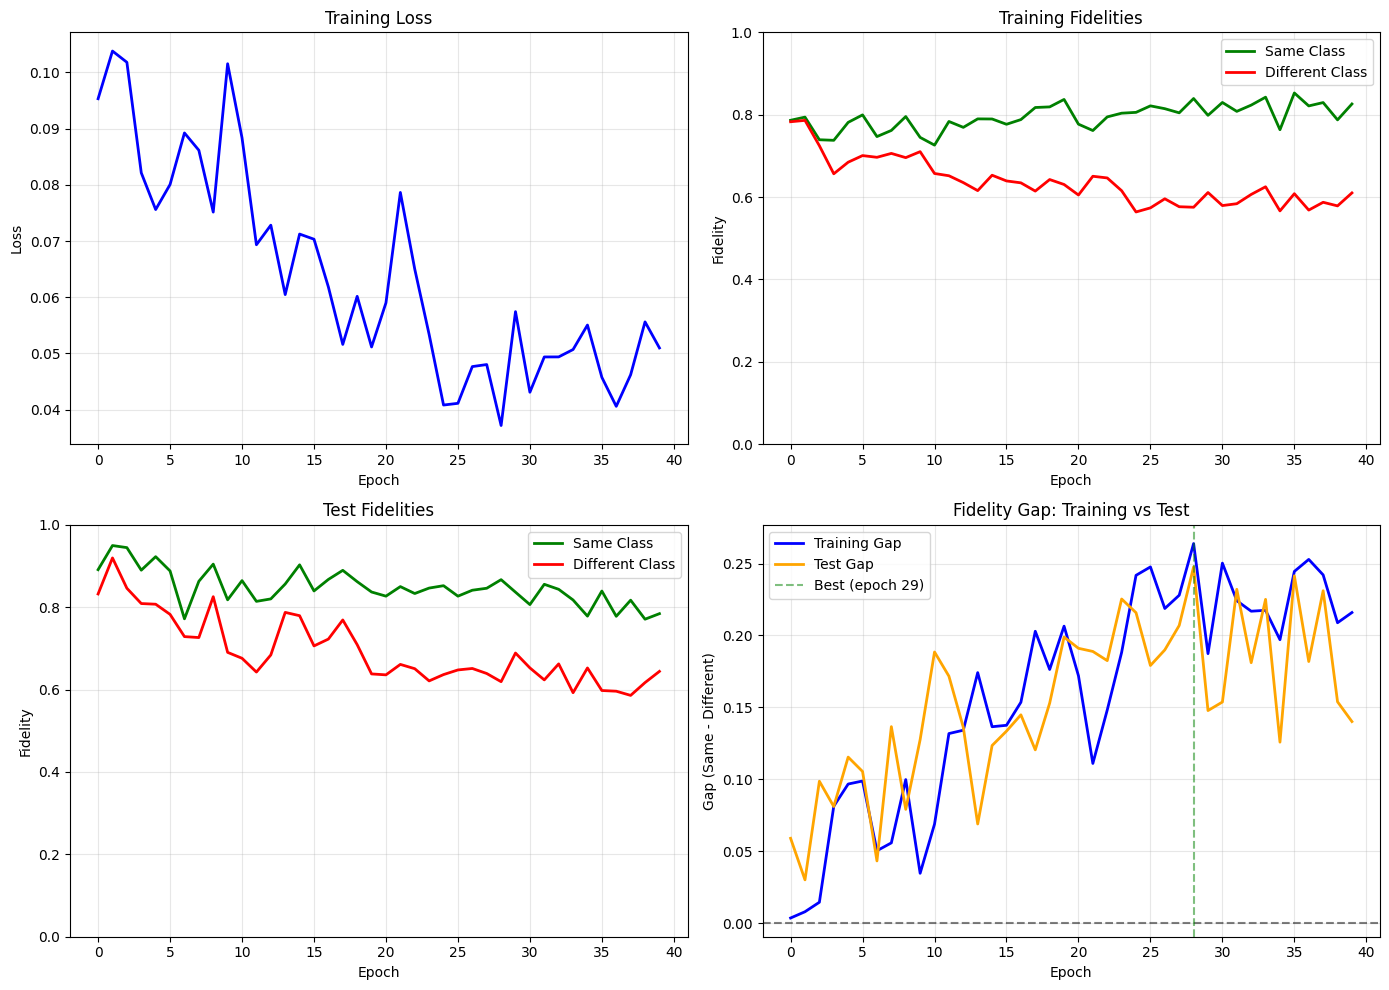

In [27]:
# Plot Training History

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Training Fidelities
axes[0, 1].plot(history['train_pos_fid'], 'g-', label='Same Class', linewidth=2)
axes[0, 1].plot(history['train_neg_fid'], 'r-', label='Different Class', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Fidelity')
axes[0, 1].set_title('Training Fidelities')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Test Fidelities
axes[1, 0].plot(history['test_pos_fid'], 'g-', label='Same Class', linewidth=2)
axes[1, 0].plot(history['test_neg_fid'], 'r-', label='Different Class', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Fidelity')
axes[1, 0].set_title('Test Fidelities')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Gap Comparison (Train vs Test)
axes[1, 1].plot(history['train_gap'], 'b-', label='Training Gap', linewidth=2)
axes[1, 1].plot(history['test_gap'], 'orange', label='Test Gap', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=best_epoch-1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Gap (Same - Different)')
axes[1, 1].set_title('Fidelity Gap: Training vs Test')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Final Evaluation on Full Test Set

print("Final evaluation on full test set...")
model.eval()

final_test_pos = []
final_test_neg = []

with torch.no_grad():
    for i in tqdm(range(len(test_pairs)), desc="Testing"):
        idx1, idx2 = test_pairs[i]
        same_class = test_labels[i]
        
        img1, _ = test_subset[idx1]
        img2, _ = test_subset[idx2]
        
        fidelity = model(img1.unsqueeze(0), img2.unsqueeze(0))
        
        if same_class:
            final_test_pos.append(fidelity.item())
        else:
            final_test_neg.append(fidelity.item())

# Results
final_gap = np.mean(final_test_pos) - np.mean(final_test_neg)

print("FINAL TEST RESULTS")
print(f"Same class fidelity:      {np.mean(final_test_pos):.4f} ± {np.std(final_test_pos):.4f}")
print(f"Different class fidelity: {np.mean(final_test_neg):.4f} ± {np.std(final_test_neg):.4f}")
print(f"Gap:                      {final_gap:.4f}")

Final evaluation on full test set...


Testing: 100%|████████████████████████████████| 200/200 [00:22<00:00,  8.76it/s]

FINAL TEST RESULTS
Same class fidelity:      0.8158 ± 0.1401
Different class fidelity: 0.6292 ± 0.1516
Gap:                      0.1866


/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_28398/1534346913.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=['Same Class', 'Different Class'], patch_artist=True)


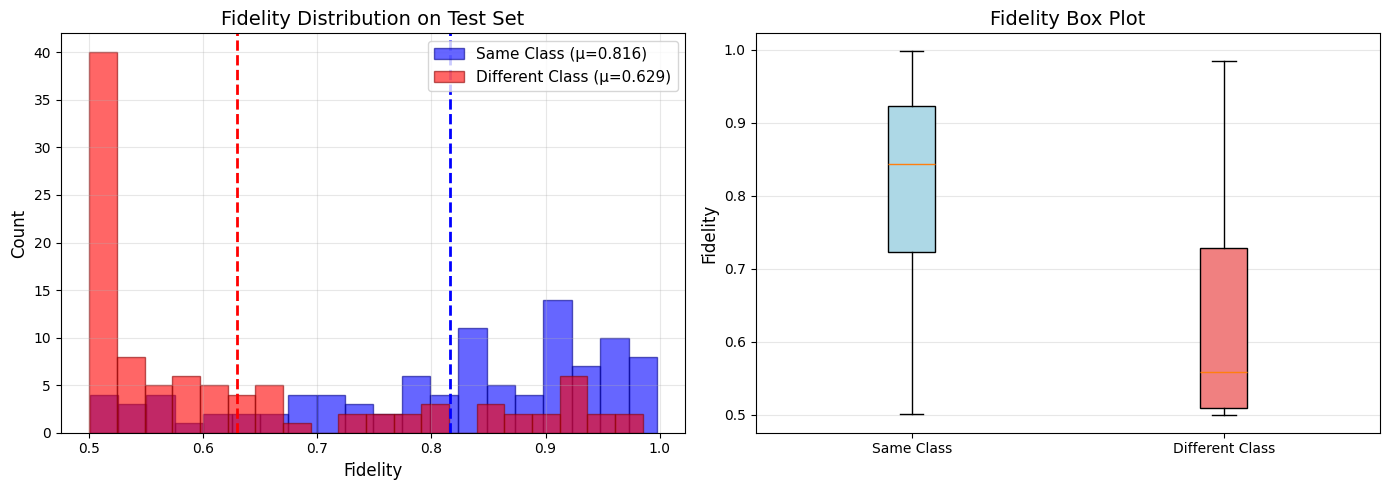

In [29]:
# Fidelity Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(final_test_pos, bins=20, alpha=0.6, 
             label=f'Same Class (μ={np.mean(final_test_pos):.3f})', 
             color='blue', edgecolor='darkblue')
axes[0].hist(final_test_neg, bins=20, alpha=0.6, 
             label=f'Different Class (μ={np.mean(final_test_neg):.3f})', 
             color='red', edgecolor='darkred')
axes[0].axvline(np.mean(final_test_pos), color='blue', linestyle='--', linewidth=2)
axes[0].axvline(np.mean(final_test_neg), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fidelity', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Fidelity Distribution on Test Set', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot
data = [final_test_pos, final_test_neg]
bp = axes[1].boxplot(data, labels=['Same Class', 'Different Class'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Fidelity', fontsize=12)
axes[1].set_title('Fidelity Box Plot', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fidelity_distribution_final.png', dpi=150, bbox_inches='tight')
plt.show()

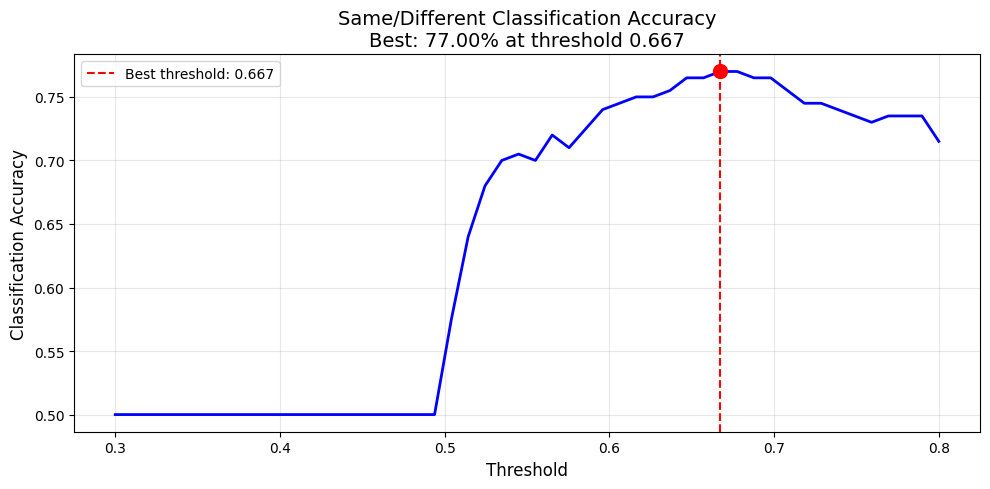

Best classification accuracy: 77.00% at threshold 0.667


In [30]:
# Classification Accuracy at Different Thresholds

thresholds = np.linspace(0.3, 0.8, 50)
accuracies = []

all_fidelities = final_test_pos + final_test_neg
all_labels = [1] * len(final_test_pos) + [0] * len(final_test_neg)

for thresh in thresholds:
    predictions = [1 if f >= thresh else 0 for f in all_fidelities]
    accuracy = sum(p == l for p, l in zip(predictions, all_labels)) / len(all_labels)
    accuracies.append(accuracy)

best_thresh_idx = np.argmax(accuracies)
best_thresh = thresholds[best_thresh_idx]
best_acc = accuracies[best_thresh_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, accuracies, 'b-', linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold: {best_thresh:.3f}')
plt.scatter([best_thresh], [best_acc], color='red', s=100, zorder=5)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title(f'Same/Different Classification Accuracy\nBest: {best_acc:.2%} at threshold {best_thresh:.3f}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('classification_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best classification accuracy: {best_acc:.2%} at threshold {best_thresh:.3f}")

In [31]:
# Summary

print("TASK VI: QUANTUM CONTRASTIVE LEARNING - SUMMARY")
print("="*70)

print(f"""
CONFIGURATION:
  - Qubits per image: {n_qubits}
  - Variational layers: {n_layers}
  - Total circuit qubits: {2*n_qubits + 1} (2 registers + ancilla)
  - Training pairs: {n_train_pairs}
  - Test pairs: {n_test_pairs}
  - Training epochs: {epochs}

ARCHITECTURE:
  - Classical encoder: 784 → 128 → LayerNorm → ReLU → Dropout(0.2) → 64 → LayerNorm → ReLU → Dropout(0.2) → {n_qubits}
  - Quantum embedding: DATA RE-UPLOADING with {n_layers} layers
    Each layer: RY(data) → [RX, RY, RZ] → Ring CNOT
  - Similarity measure: SWAP test → fidelity

KEY IMPROVEMENTS:
  1. Data re-uploading: Re-encode features at each layer for universal approximation
  2. Dropout (0.2): Prevents overfitting in classical encoder
  3. More training data: {n_train_pairs} pairs (increased from 300)
  4. Lower learning rates: 0.002 (classical), 0.02 (quantum)
  5. Learning rate scheduling: Decay by 0.5 every 15 epochs
  6. Early stopping: Best model saved at epoch {best_epoch}

FINAL RESULTS:
  - Same class fidelity:      {np.mean(final_test_pos):.4f} ± {np.std(final_test_pos):.4f}
  - Different class fidelity: {np.mean(final_test_neg):.4f} ± {np.std(final_test_neg):.4f}
  - Gap:                      {final_gap:.4f}
  - Best classification acc:  {best_acc:.2%} at threshold {best_thresh:.3f}

REFERENCE:
  - Data re-uploading: Pérez-Salinas et al., "Data re-uploading for a universal quantum classifier", Quantum 4, 226 (2020)
""")

TASK VI: QUANTUM CONTRASTIVE LEARNING - SUMMARY

CONFIGURATION:
  - Qubits per image: 8
  - Variational layers: 3
  - Total circuit qubits: 17 (2 registers + ancilla)
  - Training pairs: 800
  - Test pairs: 200
  - Training epochs: 40

ARCHITECTURE:
  - Classical encoder: 784 → 128 → LayerNorm → ReLU → Dropout(0.2) → 64 → LayerNorm → ReLU → Dropout(0.2) → 8
  - Quantum embedding: DATA RE-UPLOADING with 3 layers
    Each layer: RY(data) → [RX, RY, RZ] → Ring CNOT
  - Similarity measure: SWAP test → fidelity

KEY IMPROVEMENTS:
  1. Data re-uploading: Re-encode features at each layer for universal approximation
  2. Dropout (0.2): Prevents overfitting in classical encoder
  3. More training data: 800 pairs (increased from 300)
  4. Lower learning rates: 0.002 (classical), 0.02 (quantum)
  5. Learning rate scheduling: Decay by 0.5 every 15 epochs
  6. Early stopping: Best model saved at epoch 29

FINAL RESULTS:
  - Same class fidelity:      0.8158 ± 0.1401
  - Different class fidelity: 0.6